comparing 3 approaches:

Scaling Only (Baseline - 5 mins)
L1 Selection (Main method - 15 mins)
UMAP (Alternative - 15 mins)


## Step 1: Load and Check Data

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

In [37]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [38]:
# Define file paths
data_path = Path("data")

# Load training and validation sets (files are in current directory)
X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_val = pd.read_csv("y_val.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

print("✅ Data loaded successfully!\n")


✅ Data loaded successfully!



In [ ]:
print("=" * 60)
print("DATA SHAPES")
print("=" * 60)
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:   {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:   {y_test.shape}")
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print()

DATA SHAPES
X_train shape: (6158, 20)
X_val shape:   (1414, 20)
X_val shape:   (1589, 20)
y_train shape: (6158, 1)
y_val shape:   (1414, 1)
y_val shape:   (1589, 1)

Number of features: 20
Training samples:   6158
Validation samples: 1414
Test samples: 1589



In [40]:
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
print(f"X_train missing values: {X_train.isnull().sum().sum()}")
print(f"X_val missing values:   {X_val.isnull().sum().sum()}")
print(f"X_test missing values:   {X_val.isnull().sum().sum()}")
print(f"y_train missing values: {y_train.isnull().sum().sum()}")
print(f"y_val missing values:   {y_val.isnull().sum().sum()}")
print(f"y_testl missing values:   {y_val.isnull().sum().sum()}")
print()

MISSING VALUES CHECK
X_train missing values: 0
X_val missing values:   0
X_test missing values:   0
y_train missing values: 0
y_val missing values:   0
y_testl missing values:   0



In [16]:
print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)
print(X_train.dtypes.value_counts())
print()

DATA TYPES SUMMARY
float64    11
int64       9
Name: count, dtype: int64



In [41]:
print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print("\nClass distribution (y_train):")
print(y_train['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_train['popularity_label'].value_counts(normalize=True))
print()

print("Class distribution (y_val):")
print(y_val['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_val['popularity_label'].value_counts(normalize=True))
print()

print("Class distribution (y_test):")
print(y_test['popularity_label'].value_counts())
print("\nClass proportions:")
print(y_test['popularity_label'].value_counts(normalize=True))
print()

TARGET VARIABLE DISTRIBUTION

Class distribution (y_train):
popularity_label
Not Popular    4310
Popular        1848
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.699903
Popular        0.300097
Name: proportion, dtype: float64

Class distribution (y_val):
popularity_label
Not Popular    1015
Popular         399
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.717822
Popular        0.282178
Name: proportion, dtype: float64

Class distribution (y_test):
popularity_label
Not Popular    1140
Popular         449
Name: count, dtype: int64

Class proportions:
popularity_label
Not Popular    0.717432
Popular        0.282568
Name: proportion, dtype: float64



In [18]:
print("=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print("\nFirst 10 features:")
print(X_train.iloc[:, :10].describe())
print()


print("=" * 60)
print("DATA PREVIEW")
print("=" * 60)
print("\nX_train (first 5 rows):")
print(X_train.head())
print("\ny_train (first 10 rows):")
print(y_train.head(10))
print()

print("=" * 60)
print("✅ DATA LOADED AND VERIFIED!")
print("=" * 60)

FEATURE STATISTICS

First 10 features:
       Danceability       Energy  Loudness_norm  Speechiness  Acousticness  \
count   6158.000000  6158.000000    6158.000000  6158.000000   6158.000000   
mean       0.679738     0.635094       0.812788     0.133995      0.222857   
std        0.147769     0.169185       0.076126     0.121321      0.242651   
min        0.073000     0.005000       0.000000     0.023000      0.000000   
25%        0.589000     0.533000       0.780319     0.046000      0.039000   
50%        0.696000     0.649000       0.824133     0.081000      0.131000   
75%        0.787000     0.759000       0.861943     0.191000      0.324750   
max        0.980000     0.996000       1.000000     0.966000      0.994000   

       Instrumentalness      Valence  release_year  release_quarter  \
count       6158.000000  6158.000000   6158.000000      6158.000000   
mean           0.011886     0.480315   2018.504872         2.511692   
std            0.074622     0.224101      1.1

## Step 2: Feature Scaling

In [43]:
use_scaling = True

if use_scaling:
    # Initialize and fit scaler on training data only
    scaler = StandardScaler()
    scaler.fit(X_train)

    # Transform both train and val
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrames
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    # Save scaler
    with open('preprocessing_artifacts/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print("Scaling applied")
else:
    # No scaling: use original features (keep variable names so the rest of notebook works)
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()
    print("⚠ Scaling skipped — using original (unscaled) features")

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_val_scaled:   {X_test_scaled.shape}")

Scaling applied
X_train_scaled: (6158, 20)
X_val_scaled:   (1414, 20)
X_val_scaled:   (1589, 20)


In [20]:
# View scaled data
print("=" * 60)
print("SCALED DATA PREVIEW")
print("=" * 60)

print("\nX_train_scaled (first 5 rows):")
print(X_train_scaled.head())

print("\nX_train_scaled statistics (mean≈0, std≈1):")
print(X_train_scaled.describe())

print("\nComparison - Before vs After Scaling:")
print("\nBefore (Original X_train):")
print(X_train.head(3))
print("\nAfter (X_train_scaled):")
print(X_train_scaled.head(3))

SCALED DATA PREVIEW

X_train_scaled (first 5 rows):
   Danceability    Energy  Loudness_norm  Speechiness  Acousticness  \
0      0.461988 -0.047844       0.162009    -0.576987     -0.378585   
1      1.098170 -0.337492       0.154006     0.033013     -0.902013   
2     -2.211329  0.708787       0.067886     4.937746     -0.580537   
3     -2.218096  1.630931       0.466478    -0.486311     -0.914377   
4     -0.404302 -0.059667      -0.374908     3.453961      0.264366   

   Instrumentalness   Valence  release_year  release_quarter  release_month  \
0         -0.159298  0.194949     -1.330037        -1.339869      -0.999889   
1         -0.159298 -1.295573      1.321426        -1.339869      -1.283506   
2         -0.159298 -0.193301     -0.446216        -0.453532      -0.149039   
3         -0.159298 -1.090291      1.321426         0.432805       0.418194   
4         -0.159298  0.824181     -0.446216        -0.453532      -0.716272   

   release_day_of_week  is_friday_release  is_

## Step 3: Create baseline for preprocessing method (Scaling only)

In [21]:
# Prepare target variable
y_train_array = y_train['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_val_array = y_val['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values

# Train model
lr_baseline = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_baseline.fit(X_train_scaled, y_train_array)

# Predictions
y_train_pred = lr_baseline.predict(X_train_scaled)
y_val_pred = lr_baseline.predict(X_val_scaled)

# Metrics
train_acc = accuracy_score(y_train_array, y_train_pred)
val_acc = accuracy_score(y_val_array, y_val_pred)
train_f1 = f1_score(y_train_array, y_train_pred)
val_f1 = f1_score(y_val_array, y_val_pred)

print(f"Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}")
print(f"Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
print("\nClassification Report (Val):")
print(classification_report(y_val_array, y_val_pred, target_names=['Not Popular', 'Popular']))

Train - Accuracy: 0.6453, F1: 0.5599
Val   - Accuracy: 0.6450, F1: 0.3548

Classification Report (Val):
              precision    recall  f1-score   support

 Not Popular       0.75      0.76      0.76      1015
     Popular       0.36      0.35      0.35       399

    accuracy                           0.64      1414
   macro avg       0.56      0.55      0.55      1414
weighted avg       0.64      0.64      0.64      1414



## Step 4: L1 Regularisation for features selection

In [44]:
## Step 4: L1 Feature Selection

from sklearn.feature_selection import SelectFromModel

# Test different C values
C_values = [0.01, 0.1, 1.0]
results = []

print("=" * 60)
print("L1 FEATURE SELECTION")
print("=" * 60)

for C in C_values:
    # Train L1 model
    lr_l1 = LogisticRegression(penalty='l1', C=C, solver='liblinear', 
                                max_iter=1000, random_state=42, class_weight='balanced')
    lr_l1.fit(X_train_scaled, y_train_array)
    
    # Count selected features (non-zero coefficients)
    n_features = np.sum(lr_l1.coef_ != 0)
    
    # Predictions
    y_val_pred = lr_l1.predict(X_val_scaled)
    
    # Metrics
    val_acc = accuracy_score(y_val_array, y_val_pred)
    val_f1 = f1_score(y_val_array, y_val_pred)
    
    results.append({
        'C': C,
        'n_features': n_features,
        'val_accuracy': val_acc,
        'val_f1': val_f1
    })
    
    print(f"\nC={C}: {n_features} features | Acc={val_acc:.4f} | F1={val_f1:.4f}")

# Select best C (highest F1 score)
results_df = pd.DataFrame(results)
best_idx = results_df['val_f1'].idxmax()
best_C = results_df.loc[best_idx, 'C']

print(f"\n✅ Best C: {best_C}")
print(f"Features selected: {results_df.loc[best_idx, 'n_features']}")

# Train final L1 model with best C
lr_l1_best = LogisticRegression(penalty='l1', C=best_C, solver='liblinear',
                                  max_iter=1000, random_state=42, class_weight='balanced')
lr_l1_best.fit(X_train_scaled, y_train_array)

# Apply SelectFromModel
selector = SelectFromModel(lr_l1_best, prefit=True)
X_train_L1 = selector.transform(X_train_scaled)
X_val_L1 = selector.transform(X_val_scaled)
X_test_L1 = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X_train_scaled.columns[selector.get_support()].tolist()

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)

# Convert to DataFrame
X_train_L1 = pd.DataFrame(X_train_L1, columns=selected_features, index=X_train_scaled.index)
X_val_L1 = pd.DataFrame(X_val_L1, columns=selected_features, index=X_val_scaled.index)
X_test_L1 = pd.DataFrame(X_test_L1, columns=selected_features, index=X_test_scaled.index)

print(f"\nX_train_L1: {X_train_L1.shape}")
print(f"X_val_L1: {X_val_L1.shape}")
print(f"X_test_L1: {X_test_L1.shape}")

L1 FEATURE SELECTION

C=0.01: 10 features | Acc=0.5820 | F1=0.3876

C=0.1: 18 features | Acc=0.6485 | F1=0.3636

C=1.0: 20 features | Acc=0.6457 | F1=0.3569

✅ Best C: 0.01
Features selected: 10

Selected features (10):
['Danceability', 'Loudness_norm', 'Speechiness', 'Valence', 'release_year', 'release_month', 'release_day_of_week', 'is_friday_release', 'artist_avg_rank', 'artist_best_rank']

X_train_L1: (6158, 10)
X_val_L1: (1414, 10)
X_test_L1: (1589, 10)


## Step 5: PCA for features

In [45]:
# Initialize PCA with 95% variance retention
pca = PCA(n_components=0.95, random_state=42)

# Fit on training data and transform both sets
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Convert to DataFrames
pca_columns = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train_scaled.index)
X_val_pca = pd.DataFrame(X_val_pca, columns=pca_columns, index=X_val_scaled.index)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test_scaled.index)
# Save PCA model
with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

print(f"✅ PCA complete")
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"\nX_train_pca: {X_train_pca.shape}")
print(f"X_val_pca: {X_val_pca.shape}")
print(f"X_test_pca: {X_test_pca.shape}")

✅ PCA complete
Original features: 20
PCA components: 13
Variance explained: 0.9594

X_train_pca: (6158, 13)
X_val_pca: (1414, 13)
X_test_pca: (1589, 13)



--------------------------------------------------------------------------------
Creating variance explanation plot...
--------------------------------------------------------------------------------


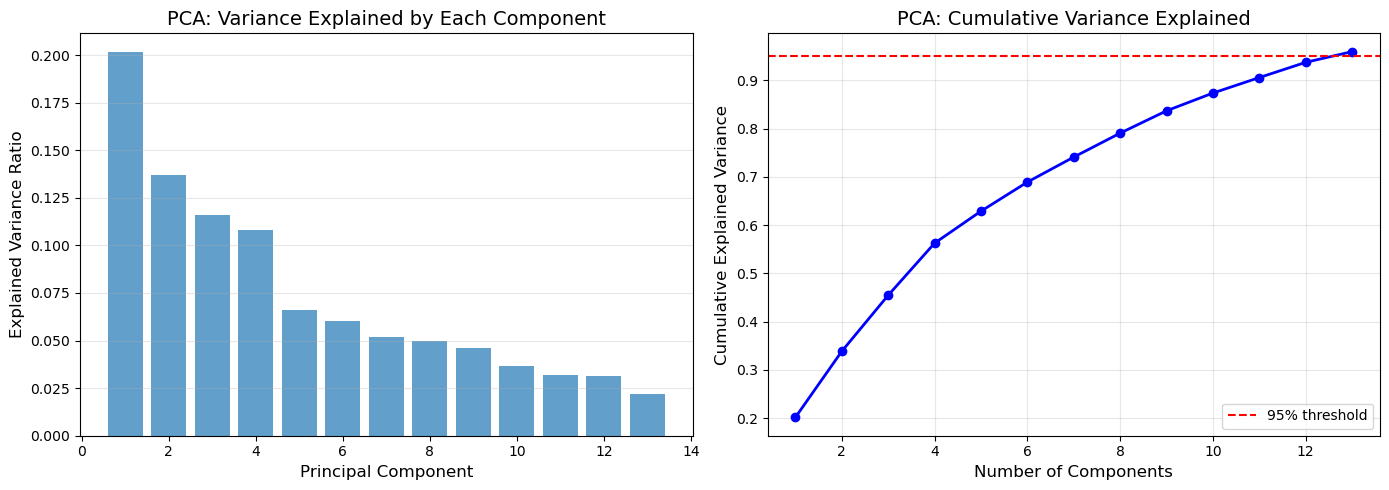

✓ Variance plot saved: pca_variance_explained.png


In [24]:
# Get number of components
n_components = X_train_pca.shape[1]

print(f"\n{'-'*80}")
print("Creating variance explanation plot...")
print(f"{'-'*80}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Explained variance per component
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('PCA: Variance Explained by Each Component', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative explained variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, n_components + 1), cumsum, 'bo-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('PCA: Cumulative Variance Explained', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Variance plot saved: pca_variance_explained.png")

In [25]:
# Get loadings for first 3 components
loadings = pca.components_[:3, :]  # First 3 components
feature_names = X_train.columns

for i, component in enumerate(loadings):
    print(f"\nPC{i+1} - Top 5 contributing features:")
    
    # Get absolute values and sort
    abs_loadings = np.abs(component)
    top_indices = abs_loadings.argsort()[-5:][::-1]
    
    for idx in top_indices:
        print(f"  {feature_names[idx]:30s}: {component[idx]:7.4f}")


PC1 - Top 5 contributing features:
  collab_avg_frequency          :  0.4966
  collab_max_frequency          :  0.4966
  collab_artist_avg_popularity  :  0.4966
  num_collab_artists            :  0.4966
  Loudness_norm                 : -0.0537

PC2 - Top 5 contributing features:
  release_month                 :  0.4624
  release_quarter               :  0.4522
  is_holiday_season             :  0.4168
  Loudness_norm                 : -0.3365
  Energy                        : -0.3291

PC3 - Top 5 contributing features:
  artist_best_rank              :  0.3888
  Energy                        :  0.3645
  artist_song_count             : -0.3533
  artist_avg_rank               :  0.3425
  Loudness_norm                 :  0.3144


## Step 6: Compare Baseline vs PCA vs L1 

In [26]:
# Store results
comparison_results = []

# 1. Baseline (Scaling Only) - Already trained
print("\n1️⃣ BASELINE (Scaling Only)")
print("-" * 80)
y_train_pred_baseline = lr_baseline.predict(X_train_scaled)
y_val_pred_baseline = lr_baseline.predict(X_val_scaled)

baseline_train_acc = accuracy_score(y_train_array, y_train_pred_baseline)
baseline_val_acc = accuracy_score(y_val_array, y_val_pred_baseline)
baseline_train_f1 = f1_score(y_train_array, y_train_pred_baseline)
baseline_val_f1 = f1_score(y_val_array, y_val_pred_baseline)

print(f"Features: {X_train_scaled.shape[1]}")
print(f"Train - Accuracy: {baseline_train_acc:.4f}, F1: {baseline_train_f1:.4f}")
print(f"Val   - Accuracy: {baseline_val_acc:.4f}, F1: {baseline_val_f1:.4f}")

comparison_results.append({
    'Method': 'Baseline (Scaling)',
    'Features': X_train_scaled.shape[1],
    'Train_Acc': baseline_train_acc,
    'Val_Acc': baseline_val_acc,
    'Train_F1': baseline_train_f1,
    'Val_F1': baseline_val_f1
})

# 2. L1 Feature Selection
print("\n2️⃣ L1 FEATURE SELECTION")
print("-" * 80)
lr_l1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_l1.fit(X_train_L1, y_train_array)

y_train_pred_l1 = lr_l1.predict(X_train_L1)
y_val_pred_l1 = lr_l1.predict(X_val_L1)

l1_train_acc = accuracy_score(y_train_array, y_train_pred_l1)
l1_val_acc = accuracy_score(y_val_array, y_val_pred_l1)
l1_train_f1 = f1_score(y_train_array, y_train_pred_l1)
l1_val_f1 = f1_score(y_val_array, y_val_pred_l1)

print(f"Features: {X_train_L1.shape[1]}")
print(f"Train - Accuracy: {l1_train_acc:.4f}, F1: {l1_train_f1:.4f}")
print(f"Val   - Accuracy: {l1_val_acc:.4f}, F1: {l1_val_f1:.4f}")

comparison_results.append({
    'Method': 'L1 Selection',
    'Features': X_train_L1.shape[1],
    'Train_Acc': l1_train_acc,
    'Val_Acc': l1_val_acc,
    'Train_F1': l1_train_f1,
    'Val_F1': l1_val_f1
})

# 3. PCA
print("\n3️⃣ PCA (95% Variance)")
print("-" * 80)
lr_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pca.fit(X_train_pca, y_train_array)

y_train_pred_pca = lr_pca.predict(X_train_pca)
y_val_pred_pca = lr_pca.predict(X_val_pca)

pca_train_acc = accuracy_score(y_train_array, y_train_pred_pca)
pca_val_acc = accuracy_score(y_val_array, y_val_pred_pca)
pca_train_f1 = f1_score(y_train_array, y_train_pred_pca)
pca_val_f1 = f1_score(y_val_array, y_val_pred_pca)

print(f"Features: {X_train_pca.shape[1]}")
print(f"Train - Accuracy: {pca_train_acc:.4f}, F1: {pca_train_f1:.4f}")
print(f"Val   - Accuracy: {pca_val_acc:.4f}, F1: {pca_val_f1:.4f}")

comparison_results.append({
    'Method': 'PCA',
    'Features': X_train_pca.shape[1],
    'Train_Acc': pca_train_acc,
    'Val_Acc': pca_val_acc,
    'Train_F1': pca_train_f1,
    'Val_F1': pca_val_f1
})

# Summary Table
print("\n" + "=" * 80)
print("SUMMARY COMPARISON")
print("=" * 80)
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

# Find best method
best_method = comparison_df.loc[comparison_df['Val_F1'].idxmax(), 'Method']
print(f"\n🏆 Best Method (Val F1): {best_method}")


1️⃣ BASELINE (Scaling Only)
--------------------------------------------------------------------------------
Features: 20
Train - Accuracy: 0.6453, F1: 0.5599
Val   - Accuracy: 0.6450, F1: 0.3548

2️⃣ L1 FEATURE SELECTION
--------------------------------------------------------------------------------
Features: 10
Train - Accuracy: 0.6393, F1: 0.5537
Val   - Accuracy: 0.6521, F1: 0.3724

3️⃣ PCA (95% Variance)
--------------------------------------------------------------------------------
Features: 13
Train - Accuracy: 0.6440, F1: 0.5556
Val   - Accuracy: 0.6612, F1: 0.3656

SUMMARY COMPARISON
            Method  Features  Train_Acc  Val_Acc  Train_F1   Val_F1
Baseline (Scaling)        20   0.645339 0.644979  0.559855 0.354756
      L1 Selection        10   0.639331 0.652051  0.553747 0.372449
               PCA        13   0.644040 0.661245  0.555556 0.365563

🏆 Best Method (Val F1): L1 Selection


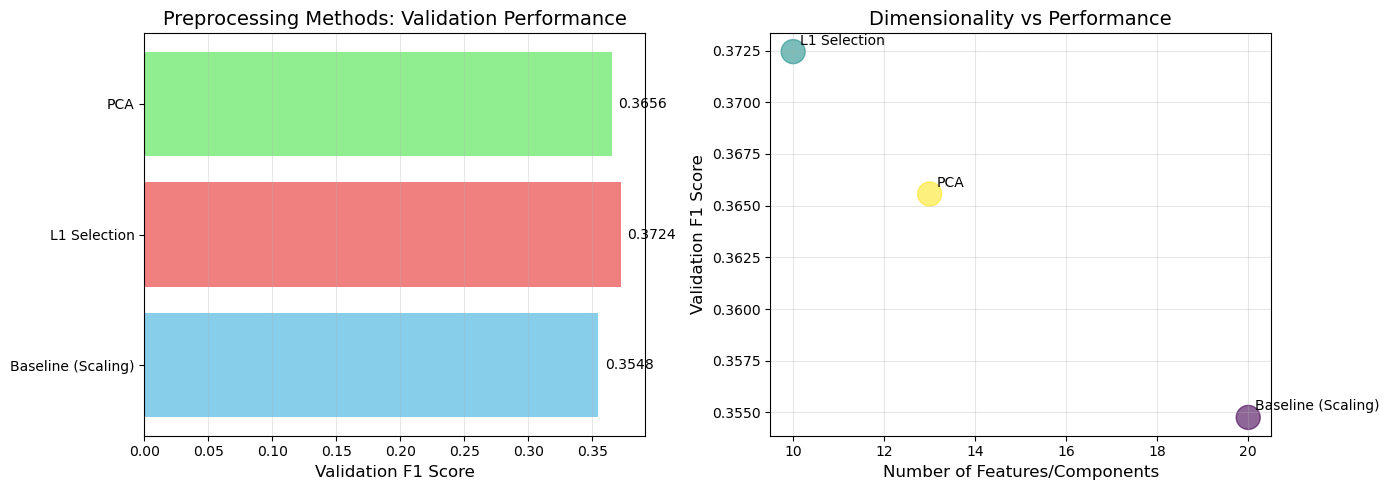

✓ Comparison plot saved: preprocessing_comparison.png


In [27]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Val F1 comparison
methods = comparison_df['Method']
val_f1s = comparison_df['Val_F1']
colors = ['skyblue', 'lightcoral', 'lightgreen']

axes[0].barh(methods, val_f1s, color=colors)
axes[0].set_xlabel('Validation F1 Score', fontsize=12)
axes[0].set_title('Preprocessing Methods: Validation Performance', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (method, score) in enumerate(zip(methods, val_f1s)):
    axes[0].text(score + 0.005, i, f'{score:.4f}', va='center', fontsize=10)

# Plot 2: Features vs Performance
axes[1].scatter(comparison_df['Features'], comparison_df['Val_F1'], 
               s=300, alpha=0.6, c=range(len(comparison_df)), cmap='viridis')

for idx, row in comparison_df.iterrows():
    axes[1].annotate(row['Method'], 
                    (row['Features'], row['Val_F1']),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[1].set_xlabel('Number of Features/Components', fontsize=12)
axes[1].set_ylabel('Validation F1 Score', fontsize=12)
axes[1].set_title('Dimensionality vs Performance', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved: preprocessing_comparison.png")

## Step 7: Hypothesis Test

In [28]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define random seeds
seeds = [42, 123, 456, 789, 1011, 2022, 3033, 4044, 5055, 6066]

# Store results
seed_results = {
    'Baseline': [],
    'L1': [],
    'PCA': []
}

print("=" * 80)
print("MULTIPLE RANDOM SEEDS TESTING")
print("=" * 80)
print(f"Testing with {len(seeds)} different random seeds...\n")

for i, seed in enumerate(seeds, 1):
    print(f"Seed {i}/{len(seeds)}: {seed}", end=" → ")
    
    # 1. BASELINE (Scaling Only)
    lr_baseline_seed = LogisticRegression(max_iter=1000, random_state=seed, class_weight='balanced')
    lr_baseline_seed.fit(X_train_scaled, y_train_array)
    y_val_pred_baseline = lr_baseline_seed.predict(X_val_scaled)
    baseline_f1 = f1_score(y_val_array, y_val_pred_baseline)
    seed_results['Baseline'].append(baseline_f1)
    
    # 2. L1 SELECTION
    lr_l1_seed = LogisticRegression(penalty='l1', C=best_C, solver='liblinear',
                                     max_iter=1000, random_state=seed, class_weight='balanced')
    lr_l1_seed.fit(X_train_scaled, y_train_array)
    selector_seed = SelectFromModel(lr_l1_seed, prefit=True)
    X_train_L1_seed = selector_seed.transform(X_train_scaled)
    X_val_L1_seed = selector_seed.transform(X_val_scaled)
    
    lr_l1_eval = LogisticRegression(max_iter=1000, random_state=seed, class_weight='balanced')
    lr_l1_eval.fit(X_train_L1_seed, y_train_array)
    y_val_pred_l1 = lr_l1_eval.predict(X_val_L1_seed)
    l1_f1 = f1_score(y_val_array, y_val_pred_l1)
    seed_results['L1'].append(l1_f1)
    
    # 3. PCA
    pca_seed = PCA(n_components=0.95, random_state=seed)
    X_train_pca_seed = pca_seed.fit_transform(X_train_scaled)
    X_val_pca_seed = pca_seed.transform(X_val_scaled)
    
    lr_pca_seed = LogisticRegression(max_iter=1000, random_state=seed, class_weight='balanced')
    lr_pca_seed.fit(X_train_pca_seed, y_train_array)
    y_val_pred_pca = lr_pca_seed.predict(X_val_pca_seed)
    pca_f1 = f1_score(y_val_array, y_val_pred_pca)
    seed_results['PCA'].append(pca_f1)
    
    print(f"Baseline: {baseline_f1:.4f} | L1: {l1_f1:.4f} | PCA: {pca_f1:.4f}")

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)

# Calculate statistics
summary_stats = []
for method in ['Baseline', 'L1', 'PCA']:
    scores = seed_results[method]
    summary_stats.append({
        'Method': method,
        'Mean_F1': np.mean(scores),
        'Std_F1': np.std(scores, ddof=1),
        'Min_F1': np.min(scores),
        'Max_F1': np.max(scores)
    })

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# Statistical Tests
print("\n" + "=" * 80)
print("STATISTICAL TESTS (Paired t-test)")
print("=" * 80)

# Baseline vs L1
t_stat_bl, p_val_bl = stats.ttest_rel(seed_results['Baseline'], seed_results['L1'])
print(f"\n1. Baseline vs L1:")
print(f"   t-statistic: {t_stat_bl:.4f}")
print(f"   p-value: {p_val_bl:.4f}")
print(f"   Result: {'Significant' if p_val_bl < 0.05 else 'Not Significant'} (α=0.05)")

# Baseline vs PCA
t_stat_bp, p_val_bp = stats.ttest_rel(seed_results['Baseline'], seed_results['PCA'])
print(f"\n2. Baseline vs PCA:")
print(f"   t-statistic: {t_stat_bp:.4f}")
print(f"   p-value: {p_val_bp:.4f}")
print(f"   Result: {'Significant' if p_val_bp < 0.05 else 'Not Significant'} (α=0.05)")

# L1 vs PCA
t_stat_lp, p_val_lp = stats.ttest_rel(seed_results['L1'], seed_results['PCA'])
print(f"\n3. L1 vs PCA:")
print(f"   t-statistic: {t_stat_lp:.4f}")
print(f"   p-value: {p_val_lp:.4f}")
print(f"   Result: {'Significant' if p_val_lp < 0.05 else 'Not Significant'} (α=0.05)")

# Best method based on mean
best_method = summary_df.loc[summary_df['Mean_F1'].idxmax(), 'Method']
print(f"\n🏆 Best Method (Mean F1 across {len(seeds)} seeds): {best_method}")
print(f"   Mean F1: {summary_df.loc[summary_df['Mean_F1'].idxmax(), 'Mean_F1']:.4f}")

MULTIPLE RANDOM SEEDS TESTING
Testing with 10 different random seeds...

Seed 1/10: 42 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 2/10: 123 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 3/10: 456 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 4/10: 789 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 5/10: 1011 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 6/10: 2022 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 7/10: 3033 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 8/10: 4044 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 9/10: 5055 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656
Seed 10/10: 6066 → Baseline: 0.3548 | L1: 0.3724 | PCA: 0.3656

RESULTS SUMMARY
  Method  Mean_F1       Std_F1   Min_F1   Max_F1
Baseline 0.354756 5.851389e-17 0.354756 0.354756
      L1 0.372449 0.000000e+00 0.372449 0.372449
     PCA 0.365563 0.000000e+00 0.365563 0.365563

STATISTICAL TESTS (Paired t-test)

1. Baseline vs L1:
   t-statistic: -inf
   p-value: 0.0000
   

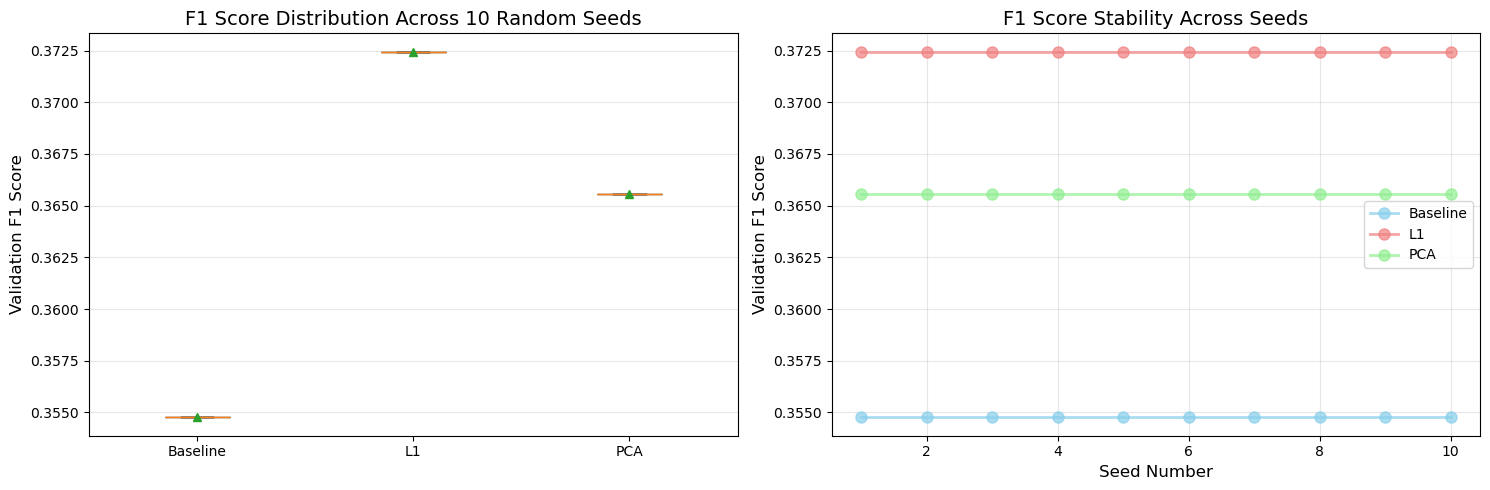

✓ Multiple seeds comparison plot saved: multiple_seeds_comparison.png


In [29]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Box plot
data_to_plot = [seed_results['Baseline'], seed_results['L1'], seed_results['PCA']]
bp = axes[0].boxplot(data_to_plot, labels=['Baseline', 'L1', 'PCA'], 
                      patch_artist=True, showmeans=True)

# Color boxes
colors = ['skyblue', 'lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[0].set_ylabel('Validation F1 Score', fontsize=12)
axes[0].set_title(f'F1 Score Distribution Across {len(seeds)} Random Seeds', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Line plot showing variance
for method, color in zip(['Baseline', 'L1', 'PCA'], colors):
    axes[1].plot(range(1, len(seeds) + 1), seed_results[method], 
                marker='o', label=method, linewidth=2, markersize=8, alpha=0.7, color=color)

axes[1].set_xlabel('Seed Number', fontsize=12)
axes[1].set_ylabel('Validation F1 Score', fontsize=12)
axes[1].set_title('F1 Score Stability Across Seeds', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiple_seeds_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Multiple seeds comparison plot saved: multiple_seeds_comparison.png")

In [30]:
from sklearn.model_selection import cross_val_score

# Define number of folds
n_folds = 5

print("=" * 80)
print("CROSS-VALIDATION ON TRAINING SET")
print("=" * 80)
print(f"Using {n_folds}-Fold Cross-Validation on Training Data Only\n")

# Store CV results
cv_results = {
    'Baseline': [],
    'L1': [],
    'PCA': []
}

# 1. BASELINE (Scaling Only)
print("1️⃣ Baseline (Scaling Only)")
print("-" * 80)
lr_baseline_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_scores = cross_val_score(lr_baseline_cv, X_train_scaled, y_train_array, 
                                   cv=n_folds, scoring='f1', n_jobs=-1)
cv_results['Baseline'] = baseline_scores
print(f"CV F1 Scores: {baseline_scores}")
print(f"Mean: {baseline_scores.mean():.4f} (±{baseline_scores.std():.4f})")

# 2. L1 SELECTION
print("\n2️⃣ L1 Feature Selection")
print("-" * 80)
lr_l1_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
l1_scores = cross_val_score(lr_l1_cv, X_train_L1, y_train_array, 
                             cv=n_folds, scoring='f1', n_jobs=-1)
cv_results['L1'] = l1_scores
print(f"CV F1 Scores: {l1_scores}")
print(f"Mean: {l1_scores.mean():.4f} (±{l1_scores.std():.4f})")

# 3. PCA
print("\n3️⃣ PCA (95% Variance)")
print("-" * 80)
lr_pca_cv = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
pca_scores = cross_val_score(lr_pca_cv, X_train_pca, y_train_array, 
                              cv=n_folds, scoring='f1', n_jobs=-1)
cv_results['PCA'] = pca_scores
print(f"CV F1 Scores: {pca_scores}")
print(f"Mean: {pca_scores.mean():.4f} (±{pca_scores.std():.4f})")

# Summary Statistics
print("\n" + "=" * 80)
print("CV SUMMARY STATISTICS")
print("=" * 80)

cv_summary = []
for method in ['Baseline', 'L1', 'PCA']:
    scores = cv_results[method]
    cv_summary.append({
        'Method': method,
        'Mean_F1': np.mean(scores),
        'Std_F1': np.std(scores, ddof=1),
        'Min_F1': np.min(scores),
        'Max_F1': np.max(scores),
        'CV_Range': np.max(scores) - np.min(scores)
    })

cv_summary_df = pd.DataFrame(cv_summary)
print(cv_summary_df.to_string(index=False))

# Statistical Tests
print("\n" + "=" * 80)
print("STATISTICAL TESTS (Paired t-test on CV folds)")
print("=" * 80)

# Baseline vs L1
t_stat_bl_cv, p_val_bl_cv = stats.ttest_rel(cv_results['Baseline'], cv_results['L1'])
print(f"\n1. Baseline vs L1:")
print(f"   t-statistic: {t_stat_bl_cv:.4f}")
print(f"   p-value: {p_val_bl_cv:.4f}")
print(f"   Result: {'Significant' if p_val_bl_cv < 0.05 else 'Not Significant'} (α=0.05)")

# Baseline vs PCA
t_stat_bp_cv, p_val_bp_cv = stats.ttest_rel(cv_results['Baseline'], cv_results['PCA'])
print(f"\n2. Baseline vs PCA:")
print(f"   t-statistic: {t_stat_bp_cv:.4f}")
print(f"   p-value: {p_val_bp_cv:.4f}")
print(f"   Result: {'Significant' if p_val_bp_cv < 0.05 else 'Not Significant'} (α=0.05)")

# L1 vs PCA
t_stat_lp_cv, p_val_lp_cv = stats.ttest_rel(cv_results['L1'], cv_results['PCA'])
print(f"\n3. L1 vs PCA:")
print(f"   t-statistic: {t_stat_lp_cv:.4f}")
print(f"   p-value: {p_val_lp_cv:.4f}")
print(f"   Result: {'Significant' if p_val_lp_cv < 0.05 else 'Not Significant'} (α=0.05)")

# Best method
best_method_cv = cv_summary_df.loc[cv_summary_df['Mean_F1'].idxmax(), 'Method']
print(f"\n🏆 Best Method (Mean CV F1): {best_method_cv}")
print(f"   Mean F1: {cv_summary_df.loc[cv_summary_df['Mean_F1'].idxmax(), 'Mean_F1']:.4f}")

CROSS-VALIDATION ON TRAINING SET
Using 5-Fold Cross-Validation on Training Data Only

1️⃣ Baseline (Scaling Only)
--------------------------------------------------------------------------------
CV F1 Scores: [0.55075377 0.53869347 0.55431472 0.54175153 0.570273  ]
Mean: 0.5512 (±0.0111)

2️⃣ L1 Feature Selection
--------------------------------------------------------------------------------
CV F1 Scores: [0.54091816 0.55179283 0.55855856 0.53977845 0.56508577]
Mean: 0.5512 (±0.0098)

3️⃣ PCA (95% Variance)
--------------------------------------------------------------------------------
CV F1 Scores: [0.55040323 0.54841998 0.56683417 0.53688525 0.57142857]
Mean: 0.5548 (±0.0127)

CV SUMMARY STATISTICS
  Method  Mean_F1   Std_F1   Min_F1   Max_F1  CV_Range
Baseline 0.551157 0.012443 0.538693 0.570273  0.031580
      L1 0.551227 0.010994 0.539778 0.565086  0.025307
     PCA 0.554794 0.014162 0.536885 0.571429  0.034543

STATISTICAL TESTS (Paired t-test on CV folds)

1. Baseline vs L1:
 

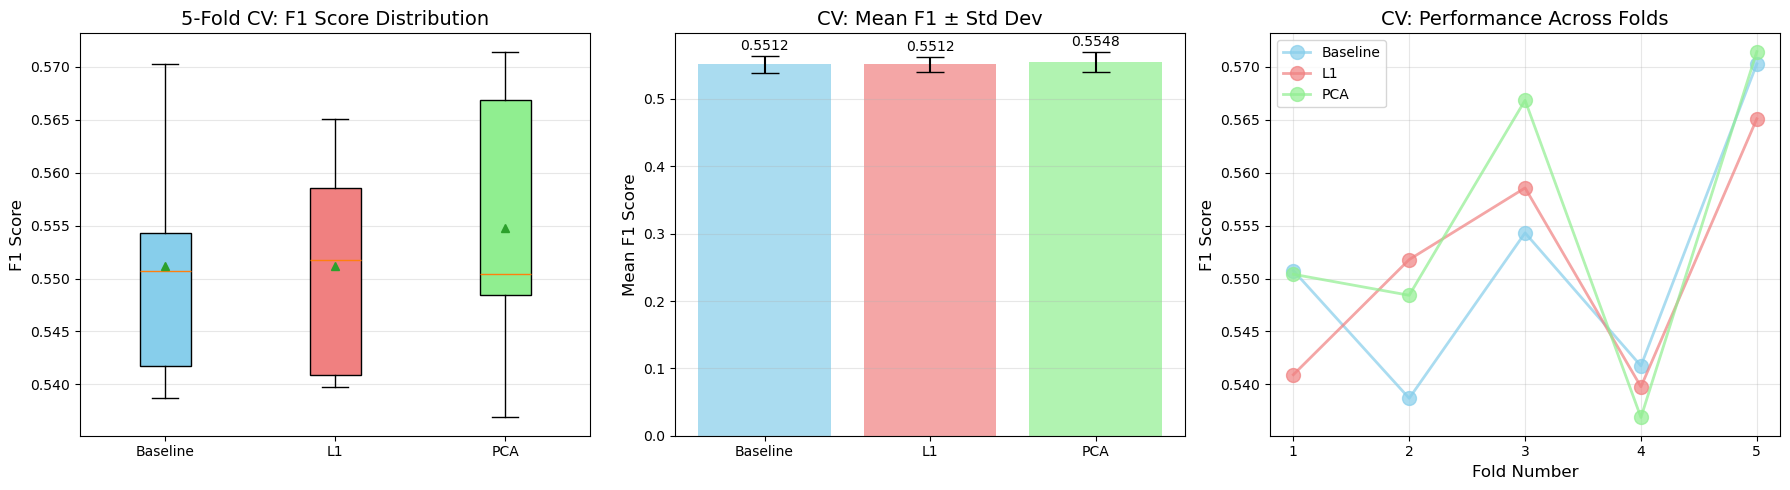

✓ Cross-validation comparison plot saved: cv_comparison.png


In [31]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Box plot of CV scores
data_to_plot_cv = [cv_results['Baseline'], cv_results['L1'], cv_results['PCA']]
bp_cv = axes[0].boxplot(data_to_plot_cv, labels=['Baseline', 'L1', 'PCA'], 
                         patch_artist=True, showmeans=True)

colors = ['skyblue', 'lightcoral', 'lightgreen']
for patch, color in zip(bp_cv['boxes'], colors):
    patch.set_facecolor(color)

axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_title(f'{n_folds}-Fold CV: F1 Score Distribution', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Bar plot with error bars
methods = cv_summary_df['Method']
means = cv_summary_df['Mean_F1']
stds = cv_summary_df['Std_F1']

axes[1].bar(methods, means, yerr=stds, capsize=10, alpha=0.7, color=colors)
axes[1].set_ylabel('Mean F1 Score', fontsize=12)
axes[1].set_title('CV: Mean F1 ± Std Dev', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, (method, mean, std) in enumerate(zip(methods, means, stds)):
    axes[1].text(i, mean + std + 0.005, f'{mean:.4f}', 
                ha='center', va='bottom', fontsize=10)

# Plot 3: Line plot showing fold-by-fold comparison
for method, color in zip(['Baseline', 'L1', 'PCA'], colors):
    axes[2].plot(range(1, n_folds + 1), cv_results[method], 
                marker='o', label=method, linewidth=2, markersize=10, 
                alpha=0.7, color=color)

axes[2].set_xlabel('Fold Number', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].set_title('CV: Performance Across Folds', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(range(1, n_folds + 1))

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cross-validation comparison plot saved: cv_comparison.png")

In [32]:
# Compare CV results with Validation Set results
print("\n" + "=" * 80)
print("COMPARISON: CV (Training) vs Validation Set")
print("=" * 80)

final_comparison = []
for method in ['Baseline', 'L1', 'PCA']:
    # Get CV mean
    cv_mean = cv_summary_df[cv_summary_df['Method'] == method]['Mean_F1'].values[0]
    
    # Get validation F1 from comparison_df (from Step 6)
    val_f1 = comparison_df[comparison_df['Method'].str.contains(method.split()[0])]['Val_F1'].values[0]
    
    final_comparison.append({
        'Method': method,
        'CV_Mean_F1': cv_mean,
        'Val_F1': val_f1,
        'Difference': val_f1 - cv_mean
    })

final_comparison_df = pd.DataFrame(final_comparison)
print(final_comparison_df.to_string(index=False))

print("\n📊 Interpretation:")
print("- CV scores: Stability on training data")
print("- Val scores: Generalization to unseen data")
print("- Small difference: Good generalization")
print("- Large difference: Potential overfitting")


COMPARISON: CV (Training) vs Validation Set
  Method  CV_Mean_F1   Val_F1  Difference
Baseline    0.551157 0.354756   -0.196402
      L1    0.551227 0.372449   -0.178778
     PCA    0.554794 0.365563   -0.189231

📊 Interpretation:
- CV scores: Stability on training data
- Val scores: Generalization to unseen data
- Small difference: Good generalization
- Large difference: Potential overfitting


So we cannot conclude L1 features is better than basline and PCA. So we will try to feed in the ML models and see the performance of the model during model selection.

## Step 8: UMAP 2D Visualization: Baseline vs L1 vs PCA

In [34]:
import umap

print("=" * 80)
print("UMAP 2D VISUALIZATION: Baseline vs L1 vs PCA")
print("=" * 80)

# ============================================================================
# STEP 1: Apply UMAP 2D to Each Preprocessing Method
# ============================================================================
print("\nApplying UMAP 2D transformation...")
print("-" * 80)

# UMAP parameters (consistent across all methods)
umap_params = {
    'n_components': 2,
    'n_neighbors': 15,
    'min_dist': 0.1,
    'metric': 'euclidean',
    'random_state': 42
}

# 1a. UMAP on Baseline
print("\n[1/3] UMAP on Baseline features...")
umap_baseline = umap.UMAP(**umap_params)
X_train_umap_baseline = umap_baseline.fit_transform(X_train_scaled)
print(f"✓ Baseline UMAP complete")

# 1b. UMAP on L1 selected features
print("\n[2/3] UMAP on L1-selected features...")
umap_l1 = umap.UMAP(**umap_params)
X_train_umap_l1 = umap_l1.fit_transform(X_train_L1)
print(f"✓ L1 UMAP complete")

# 1c. UMAP on PCA components
print("\n[3/3] UMAP on PCA components...")
umap_pca = umap.UMAP(**umap_params)
X_train_umap_pca = umap_pca.fit_transform(X_train_pca)
print(f"✓ PCA UMAP complete")

# ============================================================================
# STEP 2: Create 3-Panel Visualization
# ============================================================================
print("\n" + "-" * 80)
print("Creating visualization...")
print("-" * 80)

# Set style
sns.set_style("whitegrid")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Color settings
colors = ['#9467bd', '#ffdd57']  # Purple for class 0, Yellow for class 1
class_labels = ['Not Popular (0)', 'Popular (1)']

# Panel 1: Baseline (All features)
for class_id, color, label in zip([0, 1], colors, class_labels):
    mask = y_train_array == class_id
    axes[0].scatter(
        X_train_umap_baseline[mask, 0],
        X_train_umap_baseline[mask, 1],
        c=color,
        label=label,
        alpha=0.6,
        s=10,
        edgecolors='none'
    )

axes[0].set_xlabel('UMAP Component 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('UMAP Component 2', fontsize=12, fontweight='bold')
axes[0].set_title(f'(a) Baseline: All Features (n={X_train_scaled.shape[1]})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc='best', frameon=True, fancybox=True, shadow=True)
axes[0].grid(True, alpha=0.3)

# Panel 2: L1 Selection
for class_id, color, label in zip([0, 1], colors, class_labels):
    mask = y_train_array == class_id
    axes[1].scatter(
        X_train_umap_l1[mask, 0],
        X_train_umap_l1[mask, 1],
        c=color,
        label=label,
        alpha=0.6,
        s=10,
        edgecolors='none'
    )

axes[1].set_xlabel('UMAP Component 1', fontsize=12, fontweight='bold')
axes[1].set_ylabel('UMAP Component 2', fontsize=12, fontweight='bold')
axes[1].set_title(f'(b) L1 Selection: Selected Features (n={X_train_L1.shape[1]})', 
                  fontsize=14, fontweight='bold')
axes[1].legend(loc='best', frameon=True, fancybox=True, shadow=True)
axes[1].grid(True, alpha=0.3)

# Add selected features as text box
selected_text = "Selected:\n" + "\n".join([f"• {f}" for f in selected_features[:5]])
if len(selected_features) > 5:
    selected_text += f"\n+ {len(selected_features)-5} more"
axes[1].text(0.02, 0.98, selected_text, transform=axes[1].transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

# Panel 3: PCA
for class_id, color, label in zip([0, 1], colors, class_labels):
    mask = y_train_array == class_id
    axes[2].scatter(
        X_train_umap_pca[mask, 0],
        X_train_umap_pca[mask, 1],
        c=color,
        label=label,
        alpha=0.6,
        s=10,
        edgecolors='none'
    )

axes[2].set_xlabel('UMAP Component 1', fontsize=12, fontweight='bold')
axes[2].set_ylabel('UMAP Component 2', fontsize=12, fontweight='bold')
axes[2].set_title(f'(c) PCA: Principal Components (n={X_train_pca.shape[1]})', 
                  fontsize=14, fontweight='bold')
axes[2].legend(loc='best', frameon=True, fancybox=True, shadow=True)
axes[2].grid(True, alpha=0.3)

# Add PCA info as text box
pca_text = f"PCA Info:\n• Components: {X_train_pca.shape[1]}\n• Variance: {pca.explained_variance_ratio_.sum():.1%}"
axes[2].text(0.02, 0.98, pca_text, transform=axes[2].transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.suptitle('UMAP 2D Visualization: Preprocessing Methods Comparison', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('umap_comparison_3panel.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 3-panel visualization saved: umap_comparison_3panel.png")

AttributeError: `np.complex_` was removed in the NumPy 2.0 release. Use `np.complex128` instead.

In [ ]:
# ============================================================================
# STEP 3: Create Individual High-Quality Plots
# ============================================================================
print("\n" + "-" * 80)
print("Creating individual high-quality plots...")
print("-" * 80)

def create_individual_umap_plot(X_2d, y, title, filename, feature_info=None):
    """Create a single high-quality UMAP plot"""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot each class
    for class_id, color, label in zip([0, 1], colors, class_labels):
        mask = y == class_id
        ax.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            c=color,
            label=label,
            alpha=0.6,
            s=20,
            edgecolors='black',
            linewidth=0.5
        )
    
    ax.set_xlabel('UMAP Component 1', fontsize=14, fontweight='bold')
    ax.set_ylabel('UMAP Component 2', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', frameon=True, fancybox=True, shadow=True, fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add feature info if provided
    if feature_info:
        ax.text(0.02, 0.98, feature_info, transform=ax.transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add sample counts
    n_class_0 = np.sum(y == 0)
    n_class_1 = np.sum(y == 1)
    stats_text = f"Samples:\nClass 0: {n_class_0}\nClass 1: {n_class_1}\nTotal: {len(y)}"
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
           fontsize=10, verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✓ Saved: {filename}")

# Create individual plots
create_individual_umap_plot(
    X_train_umap_baseline, y_train_array,
    f'UMAP Visualization: Baseline (All {X_train_scaled.shape[1]} Features)',
    'umap_baseline_detailed.png',
    f"All {X_train_scaled.shape[1]} original features"
)

create_individual_umap_plot(
    X_train_umap_l1, y_train_array,
    f'UMAP Visualization: L1 Selection ({X_train_L1.shape[1]} Features)',
    'umap_l1_detailed.png',
    "Selected Features:\n" + "\n".join([f"• {f}" for f in selected_features])
)

create_individual_umap_plot(
    X_train_umap_pca, y_train_array,
    f'UMAP Visualization: PCA ({X_train_pca.shape[1]} Components)',
    'umap_pca_detailed.png',
    f"PCA: {X_train_pca.shape[1]} components\n{pca.explained_variance_ratio_.sum():.1%} variance explained"
)


--------------------------------------------------------------------------------
Creating individual high-quality plots...
--------------------------------------------------------------------------------
✓ Saved: umap_baseline_detailed.png
✓ Saved: umap_l1_detailed.png
✓ Saved: umap_pca_detailed.png


In [ ]:
# ============================================================================
# STEP 4: Analysis Summary
# ============================================================================
print("\n" + "=" * 80)
print("UMAP VISUALIZATION ANALYSIS")
print("=" * 80)

# Calculate class separation metrics
def calculate_separation(X_2d, y):
    """Calculate simple separation metric between classes"""
    class_0_center = X_2d[y == 0].mean(axis=0)
    class_1_center = X_2d[y == 1].mean(axis=0)
    separation = np.linalg.norm(class_1_center - class_0_center)
    
    class_0_spread = X_2d[y == 0].std(axis=0).mean()
    class_1_spread = X_2d[y == 1].std(axis=0).mean()
    avg_spread = (class_0_spread + class_1_spread) / 2
    
    return separation, avg_spread, separation / avg_spread

sep_baseline, spread_baseline, ratio_baseline = calculate_separation(X_train_umap_baseline, y_train_array)
sep_l1, spread_l1, ratio_l1 = calculate_separation(X_train_umap_l1, y_train_array)
sep_pca, spread_pca, ratio_pca = calculate_separation(X_train_umap_pca, y_train_array)

print("\nClass Separation Analysis:")
print(f"  {'Method':<15} {'Separation':>12} {'Avg Spread':>12} {'Ratio':>10}")
print("-" * 55)
print(f"  {'Baseline':<15} {sep_baseline:>12.3f} {spread_baseline:>12.3f} {ratio_baseline:>10.3f}")
print(f"  {'L1 Selection':<15} {sep_l1:>12.3f} {spread_l1:>12.3f} {ratio_l1:>10.3f}")
print(f"  {'PCA':<15} {sep_pca:>12.3f} {spread_pca:>12.3f} {ratio_pca:>10.3f}")

print("\n📊 Observations:")
if ratio_l1 > ratio_baseline and ratio_l1 > ratio_pca:
    print("  ✓ L1 Selection shows the best class separation")
    print("    → Classes are most distinguishable")
    print("    → Supports L1's superior performance")
elif ratio_baseline > ratio_l1 and ratio_baseline > ratio_pca:
    print("  ⚠ Baseline shows best separation")
    print("    → L1 removed some discriminative information")
elif ratio_pca > ratio_baseline and ratio_pca > ratio_l1:
    print("  ⚠ PCA shows best separation")
    print("    → Linear transformation preserved structure well")

print("\n🎯 Visual Interpretation Guide:")
print("  • Clusters well-separated → Good preprocessing")
print("  • Clusters overlapping → Poor class distinguishability")
print("  • Tight clusters → Low variance within class")
print("  • Spread clusters → High variance within class")

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETE!")
print("=" * 80)
print("\nFiles created:")
print("  1. umap_comparison_3panel.png (main figure for thesis)")
print("  2. umap_baseline_detailed.png (detailed baseline)")
print("  3. umap_l1_detailed.png (detailed L1)")
print("  4. umap_pca_detailed.png (detailed PCA)")
print("\n✅ Ready for thesis inclusion!")


UMAP VISUALIZATION ANALYSIS

Class Separation Analysis:
  Method            Separation   Avg Spread      Ratio
-------------------------------------------------------
  Baseline               0.767        5.176      0.148
  L1 Selection           0.693        4.996      0.139
  PCA                    0.835        4.188      0.199

📊 Observations:
  ⚠ PCA shows best separation
    → Linear transformation preserved structure well

🎯 Visual Interpretation Guide:
  • Clusters well-separated → Good preprocessing
  • Clusters overlapping → Poor class distinguishability
  • Tight clusters → Low variance within class
  • Spread clusters → High variance within class

VISUALIZATION COMPLETE!

Files created:
  1. umap_comparison_3panel.png (main figure for thesis)
  2. umap_baseline_detailed.png (detailed baseline)
  3. umap_l1_detailed.png (detailed L1)
  4. umap_pca_detailed.png (detailed PCA)

✅ Ready for thesis inclusion!


## Step 9: Post process for ML Training

In [46]:
import pickle
import os

# Create directory for saved models/artifacts
os.makedirs('preprocessing_artifacts', exist_ok=True)

# ============================================================================
# 1. SAVE PROCESSED DATASETS (CSV)
# ============================================================================
print("\n1️⃣ Saving processed datasets...")
print("-" * 80)

# Baseline (Scaled)
X_train_scaled.to_csv('preprocessing_artifacts/X_train_baseline.csv', index=False)
X_val_scaled.to_csv('preprocessing_artifacts/X_val_baseline.csv', index=False)
X_test_scaled.to_csv('preprocessing_artifacts/X_test_baseline.csv', index=False)
print("✓ Baseline datasets saved")

# L1 Selected Features
X_train_L1.to_csv('preprocessing_artifacts/X_train_L1.csv', index=False)
X_val_L1.to_csv('preprocessing_artifacts/X_val_L1.csv', index=False)
X_test_L1.to_csv('preprocessing_artifacts/X_test_L1.csv', index=False)
print("✓ L1 feature-selected datasets saved")

# PCA
X_train_pca.to_csv('preprocessing_artifacts/X_train_pca.csv', index=False)
X_val_pca.to_csv('preprocessing_artifacts/X_val_pca.csv', index=False)
X_test_pca.to_csv('preprocessing_artifacts/X_test_pca.csv', index=False)
print("✓ PCA datasets saved")

# Target variables (same for all)
y_train.to_csv('preprocessing_artifacts/y_train.csv', index=False)
y_val.to_csv('preprocessing_artifacts/y_val.csv', index=False)
y_test.to_csv('preprocessing_artifacts/y_test.csv', index=False)
print("✓ Target variables saved")


1️⃣ Saving processed datasets...
--------------------------------------------------------------------------------
✓ Baseline datasets saved
✓ L1 feature-selected datasets saved
✓ PCA datasets saved
✓ Target variables saved


In [ ]:
print('Hello Word')